### Import dependencies

In [17]:
import gwpy as gw
import oreonspy as op
import numpy as np
import matplotlib.pyplot as plt
import oreonspy.utils as ut


import os

In [2]:
op.__version__

'3.3.3'

In [3]:
# LASER
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2.*np.pi / lambd

In [ ]:
# Creating of the name list of the files in the folder tests/optical_cavities_testset
file_names = os.listdir("../tests/optical_cavities_testset")

print(f"Nomi dei file trovati: {file_names}")

Nomi dei file trovati: ['cavity_b82944a1-d30c-5ea5-b331-80fcc8d14b53.xml', 'cavity_7c92d2f9-280e-570f-9f08-40a62fc90c27.xml', 'cavity_ddb5cf50-ffe6-5742-8575-fa60186337f2.xml', 'cavity_0c4b9c47-5b22-5678-9107-511887fa03d8.xml', 'cavity_585bf99a-9153-54cd-b62b-50ab804f2157.xml', 'cavity_87ea86c6-0db4-578b-ba3e-fdc56a3749a6.xml', 'cavity_4b34d8f5-2234-59d2-aee3-cc782fd00a69.xml', 'cavity_582d94f8-f230-51c9-902d-f3c8c476fffa.xml', 'cavity_4469917c-b658-568e-9f45-5155da41ee3a.xml', 'cavity_f5c515ae-c684-5336-8b7e-33c07fa173d9.xml', 'cavity_99ffd79e-88b1-5065-8b53-e4417740e5f1.xml', 'cavity_b9e85ca4-33bf-5ba8-a46f-35807df3829e.xml', 'cavity_867c1990-f070-5952-a9b7-af89514cc87b.xml', 'cavity_b18956b6-987d-5fa4-8d8b-a257638ca04c.xml', 'cavity_4ca5ed57-c6d0-54ae-8b16-903b27cac8c8.xml', 'cavity_03384b46-68e3-59cc-9bf5-1c953a138a11.xml', 'cavity_c04207c3-fc1d-5a10-87fb-adb6b33e7aa4.xml', 'cavity_452af9d3-edc4-51d5-bb58-02f933dbeb2c.xml', 'cavity_2810c644-7793-55dd-8c4b-dc5c4ede4aaa.xml', 'cavity

In [ ]:
# Extracting the list of file paths
file_paths = [os.path.join("../tests/optical_cavities_testset", file_name) for file_name in file_names]

print(f"File paths trovati: {file_paths}")

File paths trovati: ['../tests/optical_cavities_testset/cavity_b82944a1-d30c-5ea5-b331-80fcc8d14b53.xml', '../tests/optical_cavities_testset/cavity_7c92d2f9-280e-570f-9f08-40a62fc90c27.xml', '../tests/optical_cavities_testset/cavity_ddb5cf50-ffe6-5742-8575-fa60186337f2.xml', '../tests/optical_cavities_testset/cavity_0c4b9c47-5b22-5678-9107-511887fa03d8.xml', '../tests/optical_cavities_testset/cavity_585bf99a-9153-54cd-b62b-50ab804f2157.xml', '../tests/optical_cavities_testset/cavity_87ea86c6-0db4-578b-ba3e-fdc56a3749a6.xml', '../tests/optical_cavities_testset/cavity_4b34d8f5-2234-59d2-aee3-cc782fd00a69.xml', '../tests/optical_cavities_testset/cavity_582d94f8-f230-51c9-902d-f3c8c476fffa.xml', '../tests/optical_cavities_testset/cavity_4469917c-b658-568e-9f45-5155da41ee3a.xml', '../tests/optical_cavities_testset/cavity_f5c515ae-c684-5336-8b7e-33c07fa173d9.xml', '../tests/optical_cavities_testset/cavity_99ffd79e-88b1-5065-8b53-e4417740e5f1.xml', '../tests/optical_cavities_testset/cavity_b9

In [ ]:
# Extracting the list of the UUIDs from the file names
UUIDS = []
for file_name in file_names:
    uuid = file_name.split('_')[1].split('.')[0]
    UUIDS.append(uuid)
print(len(UUIDS))

99


In [ ]:
import xml.etree.ElementTree as ET

# Path of the XML file
file_path = '../tests/optical_cavities.xml'

# Parsing of the XML file
tree = ET.parse(file_path)
root = tree.getroot()

# List to store UUIDs of the cavities to load
UUIDS_to_load = []

# Extracting the wanted UUIDs from the XML file
for cavity in root.findall('Cavity'):
    uuid_element = cavity.find('UUID')
    if uuid_element is not None:
        UUIDS_to_load.append(uuid_element.text)

# Printing the UUIDs to load
print(f"Totale UUID trovati: {len(UUIDS_to_load)}")

Totale UUID trovati: 99


In [8]:
# Filter and parse cavities with UUIDs present in UUIDS
filtered_cavities = []
filtered_UUIDS = []

for file_path in file_paths:
    cavity = op.Cavity()
    uuid = file_name.split('_')[1].split('.')[0]
    if uuid in UUIDS_to_load:
        filtered_UUIDS.append(uuid)
        #print(uuid)
        #print(f"Parsing cavity: {file_name}")
        cavity.xml_load(file_path)
        # print(cavity)
        #print(f"Finesse: {cavity.Finesse()}", f"Length: {cavity.__L__}")
        filtered_cavities.append(cavity)    

# Select one cavity every five
selected_cavities = filtered_cavities[::5]
selected_UUIDS = filtered_UUIDS[::5]
print(f"Selected {len(selected_cavities)} cavities from the filtered list.")

Selected 20 cavities from the filtered list.


In [16]:
print(selected_cavities[0])
print(selected_UUIDS[0])

2def98c7-94f9-5e6e-b19a-ada98530929e


In [9]:
cavity = selected_cavities[0]

In [10]:
cavity.print_params()
v_cr = ut.critical_velocity(cavity, wavelength=ut.lambd, L=cavity.__L__, Finesse=cavity.Finesse())
velocity_factor = 5
f_calc = ut.optimal_sampling_frequency(cavity=cavity, critical_velocity_factor=velocity_factor)
print(f"Critical velocity: {v_cr}")
print(f"Optimal sampling frequency: {f_calc}")

Coefficient of finesse: 77404.26
Half round-trip time: 1.81e-07 [s]
Effective number of photon round trip: 139
Tau_s: 4.46e-03 [s]
Finesse: 437.02
Gain: 1.95
Critical velocity: 2.415810313682922e-05
Optimal sampling frequency: 594890.6271522451


In [11]:
num_points, time_steps = ut.generate_time_points_for_constant_velocity(velocity=v_cr*velocity_factor, f_calc= f_calc)

In [12]:
# LASER
E_in_avg = 1.+0.j  #

def generate_cavity_evolution(cavity, z_evolution, E_evolution, title=None):
    results = np.zeros(num_points, dtype=np.complex128)

    for t in range(num_points):
        results[t], _ = cavity.sim_step(E_evolution[t], d_zeta=z_evolution[t]-z_evolution[t-1], )
    
    s = np.abs(results)**2
    ph = np.angle(results)
    pdh = ut.V_pdh(0., E_evolution, results)
    
    print(f"Results for v = {velocity_factor} v_cr and f_calc = {f_calc} Hz:")
    #print(results)

    simple_plot = False
    if simple_plot is False:
        ut.plot_cavity_evolution(z_evolution, E_evolution, s, ph, pdh, zeta1_positons=None, s_ref=None, ph_ref=None, title=title)
    else:
        plt.plot(time_steps, s)
        plt.plot(time_steps, ph)
        plt.plot(time_steps, pdh)
        plt.xlabel('Time (s)')
        plt.ylabel('Cavity Evolution')
        plt.title(f'Cavity Evolution for v = {velocity_factor} v_cr and f_calc = {f_calc} Hz')
        plt.show()
    return s, ph, pdh

Results for v = 5 v_cr and f_calc = 594890.6271522451 Hz:


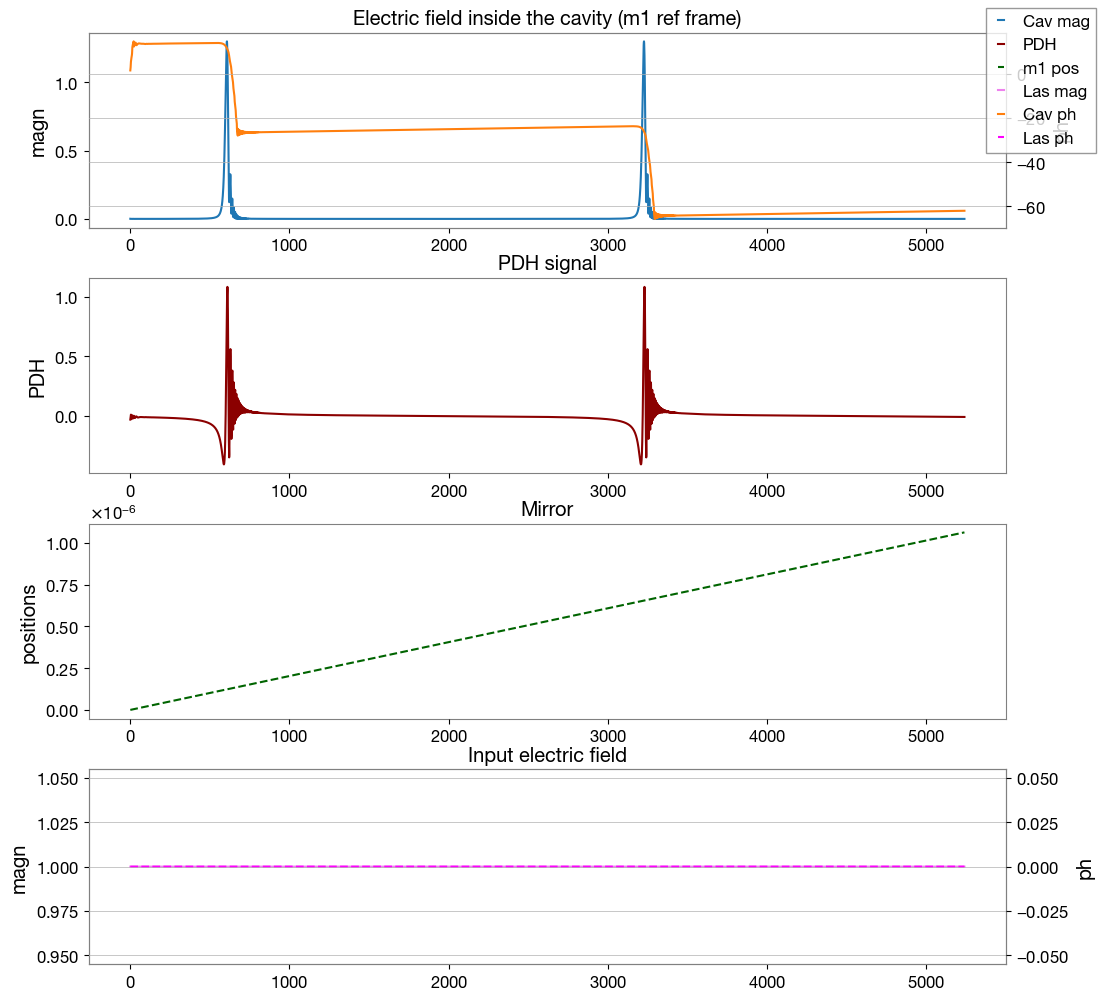

In [ ]:
# Define velocities and f_calc range
# velocity_factors = np.array([0.1, 1, 2, 5, 10])
# frequency_factors = np.array([1, 3, 10])

E_ev = np.ones(num_points)

cavity.simulation(ut.k, f_calc, E_ev[0])

z_ev = np.linspace(0., ut.lambd, num_points) 

s, ph, pdh = generate_cavity_evolution(cavity, z_ev, E_ev)




### Simulatng with low frequency

881
Results for v = 5 v_cr and f_calc = 594890.6271522451 Hz:


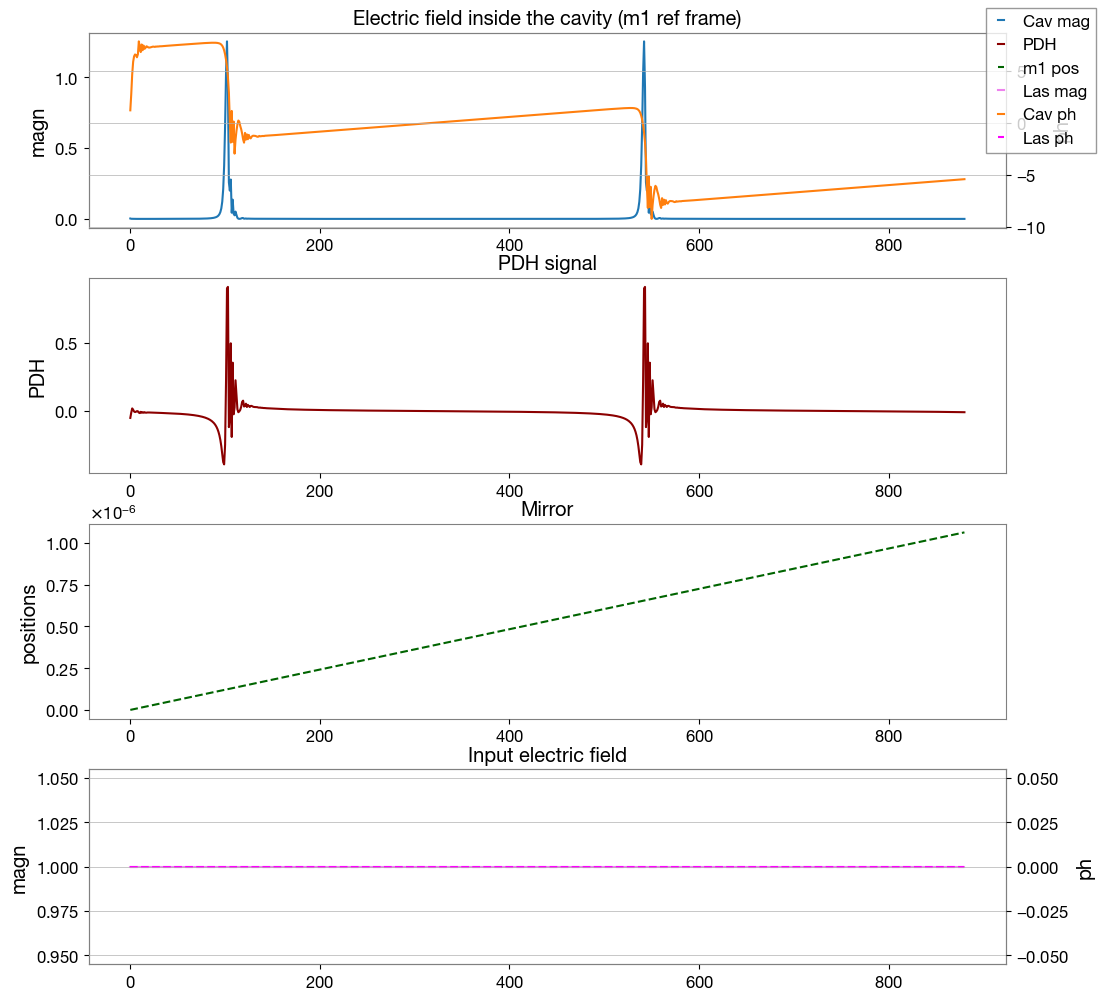

In [ ]:
f_low = 100e3

num_points, time_steps = ut.generate_time_points_for_constant_velocity(velocity=v_cr*velocity_factor, f_calc = f_low)
print(num_points)
E_ev = np.ones(num_points)

cavity.simulation(ut.k, f_low, E_ev[0])

z_ev = np.linspace(0., ut.lambd, num_points) 

s_low, ph_low, pdh_low = generate_cavity_evolution(cavity, z_ev, E_ev)



### Resampling of the time series and plotting

Points for high frequency: {5241}
Points for low frequency: {881}
Points for resampled series:881


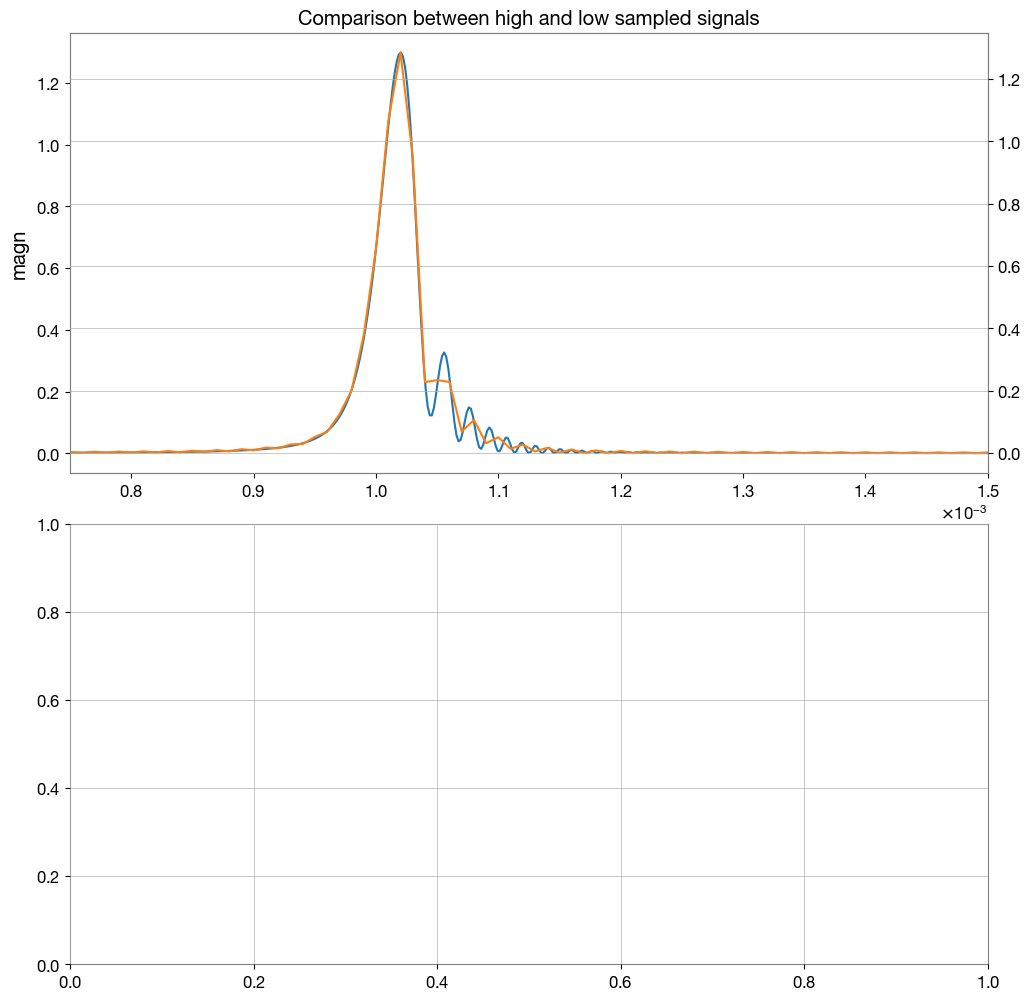

In [26]:
from gwpy.timeseries import TimeSeries

s_high = TimeSeries(s, sample_rate=f_calc)
s_low= TimeSeries(s_low, sample_rate=f_low)
s_high_resampled = s_high.resample(rate= f_low)

print("Points for high frequency: {0}". format({len(s_high)}))
print('Points for low frequency: {0}'.format({len(s_low)}))
print("Points for resampled series:{0}".format(len(s_high_resampled)))

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
fig.tight_layout()
ax[0].plot(s_high, label="High sampled")
ax[0].grid()
ax[0].set_ylabel("magn")
ax[0].title.set_text("Comparison between high and low sampled signals")
ax[0].set_xlim(0.00075,0.0015)
ax2 = ax[0].twinx()

ax2.plot(s_high_resampled, label="low_sampled", color='tab:orange')
ax2.tick_params(axis='y')

plt.show()